# Customer Churn Final Project
## by Kira Damo, Kuangdong Sun, Dilly Nguyen


# Step 1: Introduction
Subscriptions are more commonly offered as a predictable form of revenue for companies. Subscriptions guarantee recurring revenue and customer loyalty. Subscriptions create an illusion to customers that a low monthly rate is a better value than a more expensive one-time payment. Customer churn is when a customer decides to end their subscription. This project aims to evaluate and investigate the driving factors in customer churn rates. By applying different models, we aim to compare model performance and see which model will have a good result for customer churn.

# Step 2: Import Required Libraries and Step 3: Load Dataset

This dataset was sourced from Kaggle and the curator already split the datasets into training and testing. The training data consists of 64,374 customer records. Each customer is distinguished by a Customer ID. The features are age, gender, tenure, usage frequency, support calls, payment delay, subscription type, contract length, total spend, last interaction, and churn.

[Link to dataset](https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset?select=customer_churn_dataset-training-master.csv)

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn_dataset-testing-master.csv to customer_churn_dataset-testing-master.csv
Saving customer_churn_dataset-training-master.csv to customer_churn_dataset-training-master.csv


In [ ]:
train_df = pd.read_csv('customer_churn_dataset-training-master.csv')
test_df = pd.read_csv('customer_churn_dataset-testing-master.csv')

In [ ]:
print('Test Data size:', len(test_df))
print('Train Data size: ', len(train_df))
total_df_size = len(test_df) + len(train_df)

# Calculate and store the percentages as variables
train_pct = 100 * (len(train_df) / total_df_size)
test_pct = 100 * (len(test_df) / total_df_size)

print(f'Training testing split: {train_pct:.2f}% / {test_pct:.2f}%')

Test Data size: 64374
Train Data size:  440833
Training testing split: 87.26% / 12.74%


In [ ]:
440833 + 64374

505207

## Step 4: Initial Data Inspection

In [ ]:
train_df.dtypes

,0
CustomerID,float64
Age,float64
Gender,object
Tenure,float64
Usage Frequency,float64
Support Calls,float64
Payment Delay,float64
Subscription Type,object
Contract Length,object
Total Spend,float64


In [ ]:
train_df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [ ]:
test_df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [ ]:
train_df.head(10)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
5,8.0,51.0,Male,33.0,25.0,9.0,26.0,Premium,Annual,129.0,8.0,1.0
6,9.0,58.0,Female,49.0,12.0,3.0,16.0,Standard,Quarterly,821.0,24.0,1.0
7,10.0,55.0,Female,37.0,8.0,4.0,15.0,Premium,Annual,445.0,30.0,1.0
8,11.0,39.0,Male,12.0,5.0,7.0,4.0,Standard,Quarterly,969.0,13.0,1.0
9,12.0,64.0,Female,3.0,25.0,2.0,11.0,Standard,Quarterly,415.0,29.0,1.0


In [ ]:
test_df.head(10)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
5,6,30,Male,41,14,10,10,Premium,Monthly,500,29,0
6,7,47,Female,37,15,9,28,Basic,Quarterly,574,14,1
7,8,54,Female,36,11,0,18,Standard,Monthly,323,16,0
8,9,36,Male,20,5,10,8,Basic,Monthly,687,8,0
9,10,65,Male,8,4,2,23,Basic,Annual,995,10,0


## Step 5: Data Cleaning

To clean the data, all NA values must be dropped. Additionally, the data types in the test data must mirror the types in the training data.

In [ ]:
train_df.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [ ]:
train_df = train_df.dropna()
train_df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [ ]:
train_df.dtypes

,0
CustomerID,float64
Age,float64
Gender,object
Tenure,float64
Usage Frequency,float64
Support Calls,float64
Payment Delay,float64
Subscription Type,object
Contract Length,object
Total Spend,float64


In [ ]:
train_df['Churn'] = train_df['Churn'].astype(int)
train_df['CustomerID'] = train_df['CustomerID'].astype(int)

In [ ]:
test_df.dtypes

,0
CustomerID,int64
Age,int64
Gender,object
Tenure,int64
Usage Frequency,int64
Support Calls,int64
Payment Delay,int64
Subscription Type,object
Contract Length,object
Total Spend,int64


In [ ]:
test_df[['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
        'Payment Delay', 'Total Spend', 'Last Interaction']] = test_df[['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
        'Payment Delay', 'Total Spend', 'Last Interaction']].astype(float)
test_df['CustomerID'] = test_df['CustomerID'].astype(int)

In [ ]:
test_df.dtypes

,0
CustomerID,int64
Age,float64
Gender,object
Tenure,float64
Usage Frequency,float64
Support Calls,float64
Payment Delay,float64
Subscription Type,object
Contract Length,object
Total Spend,float64


In [ ]:
test_df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


### Outlier Detection
Before proceeding with feature engineering, we need to identify potential outliers in the numerical features to ensure they don't negatively impact our model performance.

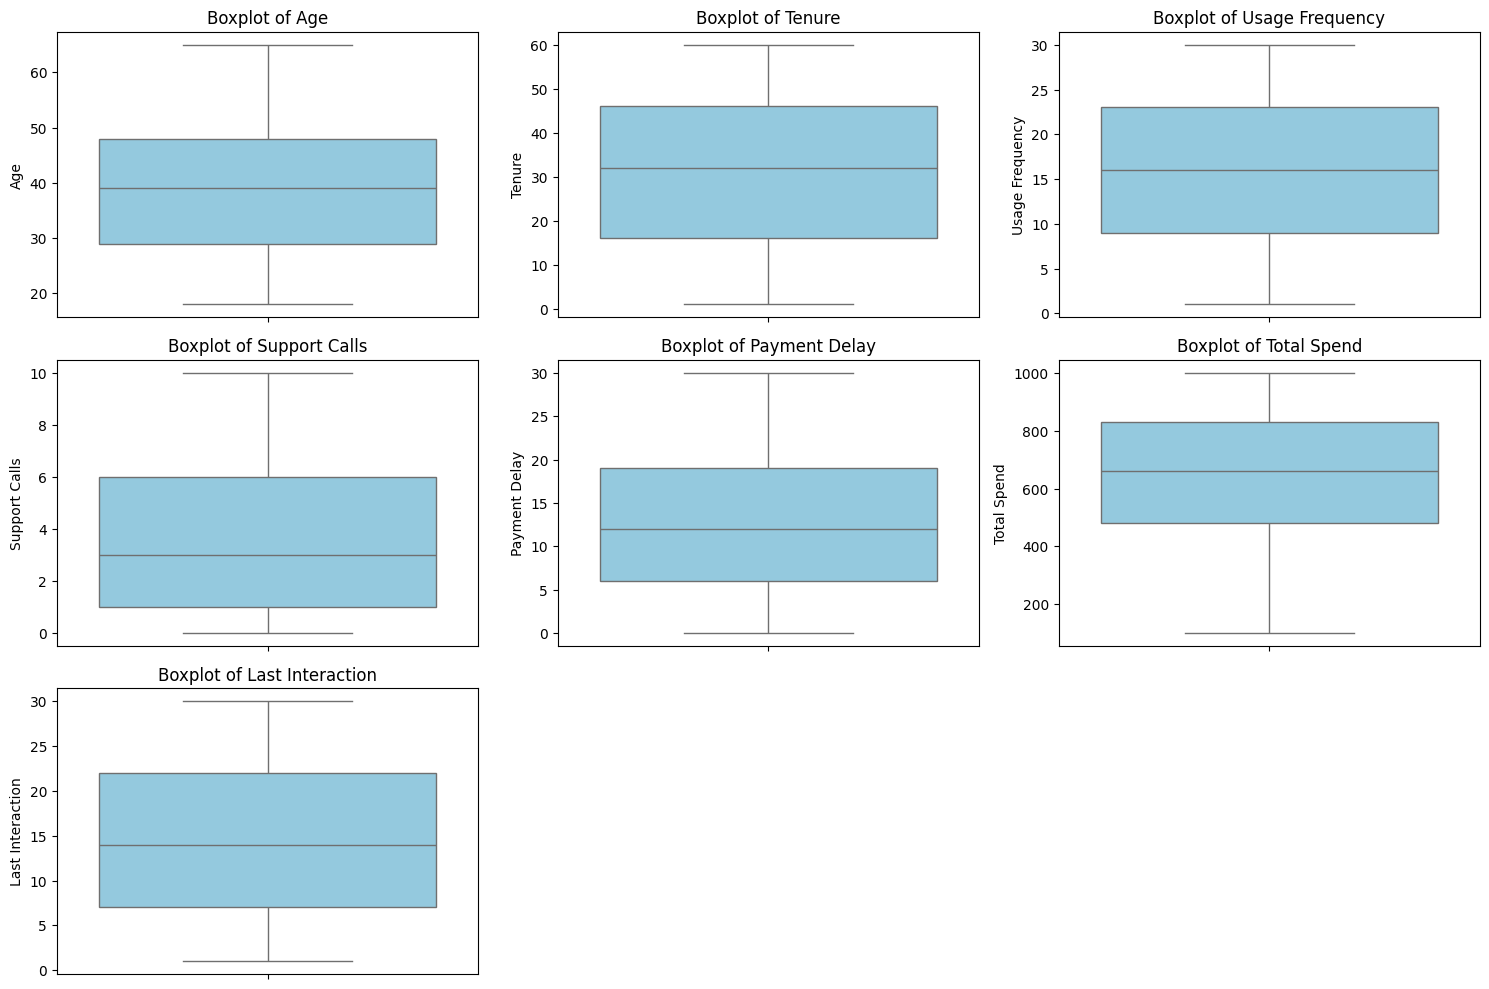

--- Outlier Statistics (IQR Method) ---
Age: Found 0 potential outliers
Tenure: Found 0 potential outliers
Usage Frequency: Found 0 potential outliers
Support Calls: Found 0 potential outliers
Payment Delay: Found 0 potential outliers
Total Spend: Found 0 potential outliers
Last Interaction: Found 0 potential outliers


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define numerical columns for checking
num_features = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']

# 1. Visualize outliers using boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=train_df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# 2. Calculate the number of outliers using the IQR method
print("--- Outlier Statistics (IQR Method) ---")
for col in num_features:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)]
    print(f"{col}: Found {len(outliers)} potential outliers")

# Step 6: Exploratory Data Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

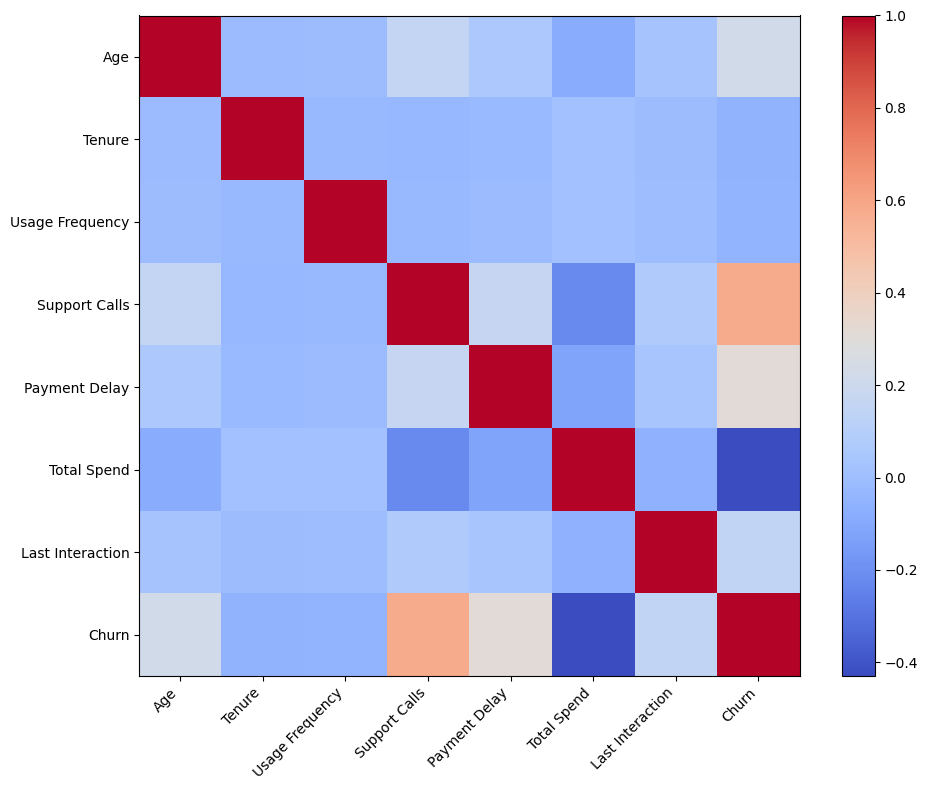

In [ ]:
train_df_num = train_df[['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction','Churn']]
train_corr_mat = train_df_num.corr()
fig, ax = plt.subplots(figsize = (10, 8))
im = ax.imshow(train_corr_mat, cmap= 'coolwarm')

cbar = ax.figure.colorbar(im, ax=ax)
ax.set_xticks(range(len(train_corr_mat.columns)))
ax.set_yticks(range(len(train_corr_mat.columns)))
ax.set_xticklabels(train_corr_mat.columns, rotation=45, ha="right")
ax.set_yticklabels(train_corr_mat.columns)

fig.tight_layout()
plt.show()

There is high correlation between support calls and churn and closely after is payment delay. This can potentially indicate that customers that seek support are more likely to churn or if their payments are delayed they may churn as well.

There is a highly negative correlation between Total Spend and churn. This can indicate that the more a customer spends on a subscription, the less likely they are to churn.

Correlation does not indicate causation and while these variables may be highly correlated, further modeling and context will need to be performed and investigated.

In [ ]:
train_corr_mat = train_df_num.corr()
train_corr_mat

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
Age,1.000000,-0.011630,-0.007190,0.158451,0.061738,-0.084684,0.028980,0.218394
Tenure,-0.011630,1.000000,-0.026800,-0.027640,-0.016588,0.019006,-0.006903,-0.051919
Usage Frequency,-0.007190,-0.026800,1.000000,-0.022013,-0.014470,0.018631,-0.004662,-0.046101
Support Calls,0.158451,-0.027640,-0.022013,1.000000,0.162889,-0.221594,0.077684,0.574267
Payment Delay,0.061738,-0.016588,-0.014470,0.162889,1.000000,-0.121044,0.042708,0.312129
Total Spend,-0.084684,0.019006,0.018631,-0.221594,-0.121044,1.000000,-0.056890,-0.429355
Last Interaction,0.028980,-0.006903,-0.004662,0.077684,0.042708,-0.056890,1.000000,0.149616
Churn,0.218394,-0.051919,-0.046101,0.574267,0.312129,-0.429355,0.149616,1.000000


This is a distribution of the numeric values using scatterplots and histograms. The blue indicates return and the 1 indicates churn.

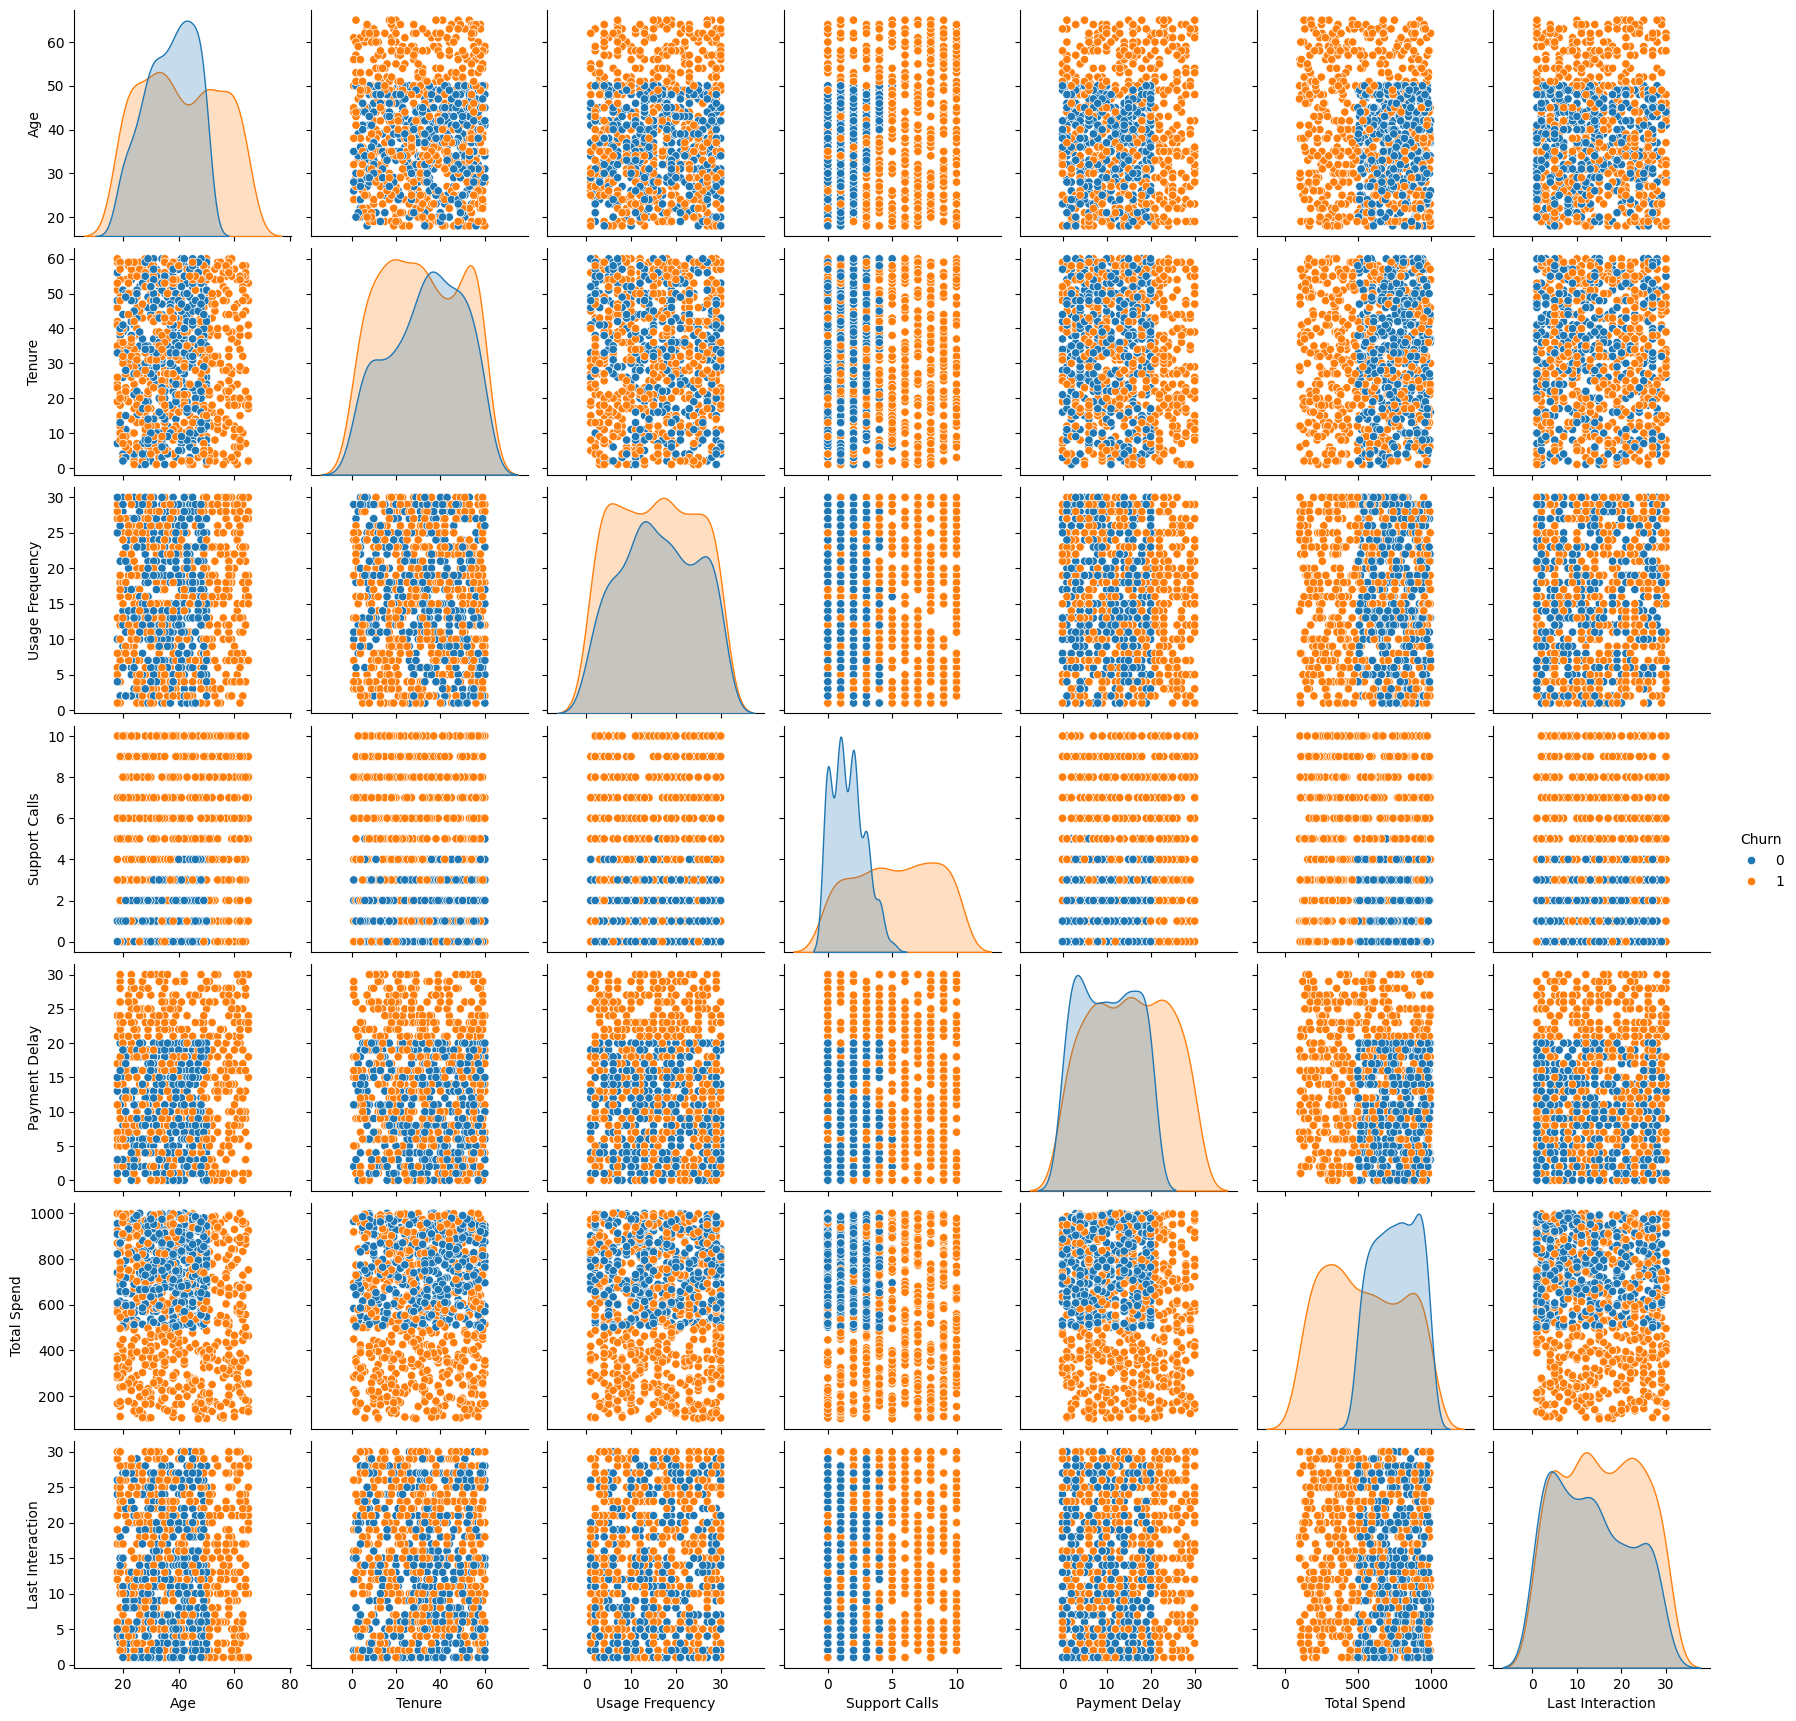

In [ ]:
train_df_num_cols = train_df[['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction','Churn']]
df_sample = train_df_num_cols.sample(n = 1000, random_state=42)
sns.pairplot(df_sample, hue='Churn')

plt.show()

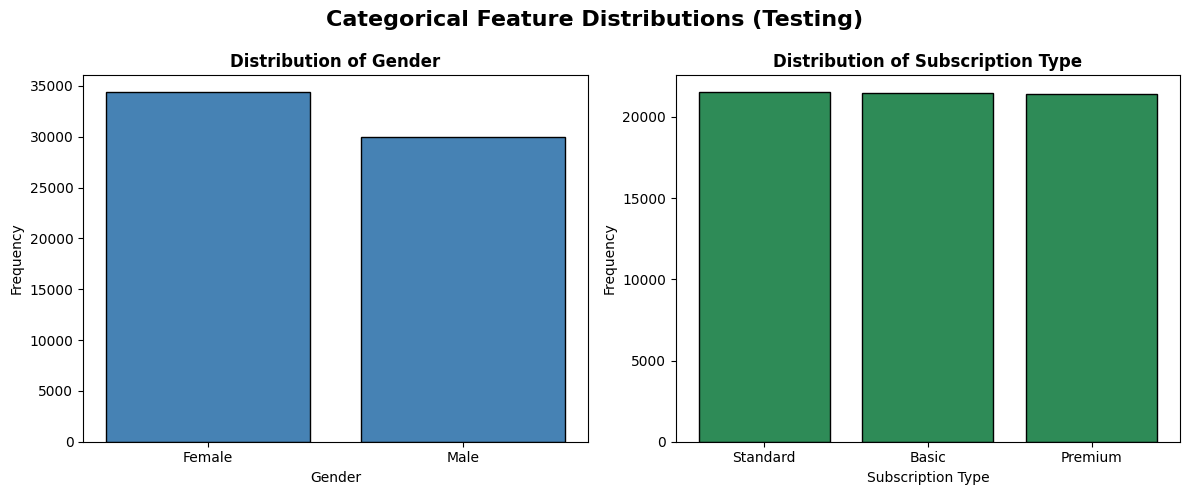

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

gender_counts = test_df["Gender"].value_counts()
ax[0].bar(x=gender_counts.index, height=gender_counts.values, fill='Gender', color='steelblue', edgecolor='k')
ax[0].set_title("Distribution of Gender", fontweight='bold')
ax[0].set_xlabel("Gender")
ax[0].set_ylabel("Frequency")

sub_counts = test_df["Subscription Type"].value_counts()
ax[1].bar(x=sub_counts.index, height=sub_counts.values, color='seagreen', edgecolor='k')
ax[1].set_title("Distribution of Subscription Type", fontweight='bold')
ax[1].set_xlabel("Subscription Type")
ax[1].set_ylabel("Frequency")

fig.suptitle("Categorical Feature Distributions (Testing)", fontsize=16, fontweight='bold')
fig.tight_layout()
fig.subplots_adjust(top=0.85)
plt.show()

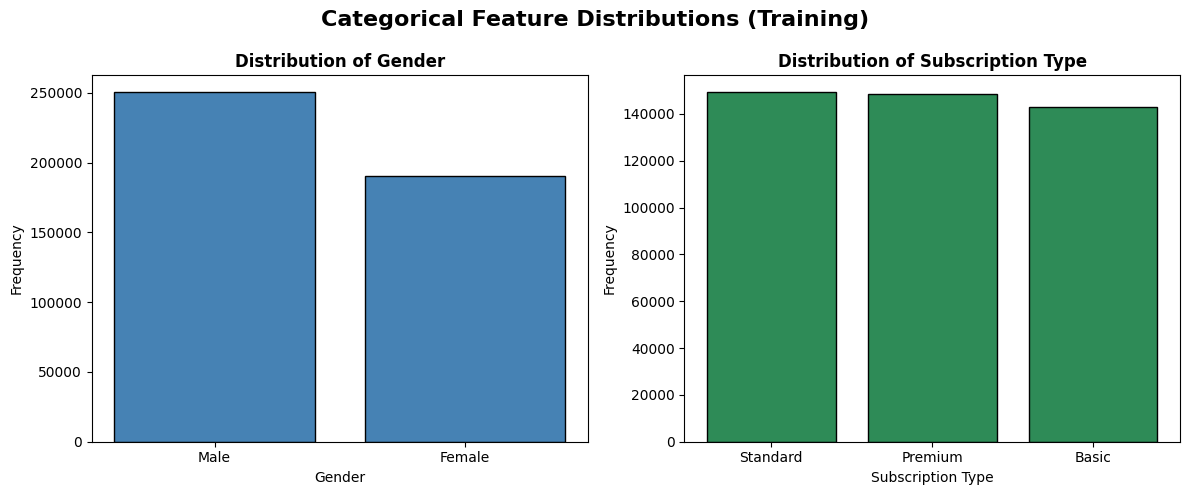

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

gender_counts = train_df["Gender"].value_counts()
ax[0].bar(x=gender_counts.index, height=gender_counts.values, fill='Gender', color='steelblue', edgecolor='k')
ax[0].set_title("Distribution of Gender", fontweight='bold')
ax[0].set_xlabel("Gender")
ax[0].set_ylabel("Frequency")

sub_counts = train_df["Subscription Type"].value_counts()
ax[1].bar(x=sub_counts.index, height=sub_counts.values, color='seagreen', edgecolor='k')
ax[1].set_title("Distribution of Subscription Type", fontweight='bold')
ax[1].set_xlabel("Subscription Type")
ax[1].set_ylabel("Frequency")

fig.suptitle("Categorical Feature Distributions (Training)", fontsize=16, fontweight='bold')
fig.tight_layout()
fig.subplots_adjust(top=0.85)
plt.show()

The distribution of the categorical variables is more even in the testing data than the training data. This can potentially benefit our modeling when performing evaluations. The difference in variation in both datasets will make over or underfitting much more apparent.

# Step 7. Feature Selection and Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Feature Selection: Drop CustomerID as it doesn't help in prediction
train_prep = train_df.drop(columns=['CustomerID', 'Contract Length'])
test_prep = test_df.drop(columns=['CustomerID', 'Contract Length'])

# 2. Categorical Encoding: Convert categorical variables into dummy/indicator variables
# We handle both train and test to ensure they have the same columns
categorical_cols = ['Gender', 'Subscription Type'] # Removed 'Contract Length'
train_prep = pd.get_dummies(train_prep, columns=categorical_cols, drop_first=True)
test_prep = pd.get_dummies(test_prep, columns=categorical_cols, drop_first=True)

# Ensure test set has the same columns as train set after dummies
test_prep = test_prep.reindex(columns=train_prep.columns, fill_value=0)

print("Encoded columns:", train_prep.columns.tolist())

# 3. Feature Scaling: Standardize numerical features
scaler = StandardScaler()
num_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']

train_prep[num_cols] = scaler.fit_transform(train_prep[num_cols])
test_prep[num_cols] = scaler.transform(test_prep[num_cols])

display(train_prep.head())

Encoded columns: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn', 'Gender_Male', 'Subscription Type_Premium', 'Subscription Type_Standard']


,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard
0,-0.753326,0.448760,-0.210511,0.454549,0.609620,1.247427,0.293052,1,False,False,True
1,2.059646,1.028278,-1.724562,2.083100,-0.601319,-0.309865,-0.986584,1,False,False,False
2,1.255940,-1.000036,-1.375166,0.780259,0.609620,-1.854698,-1.335575,1,False,False,False
3,1.497051,0.390808,0.604748,1.105969,-0.722413,-0.978462,1.689018,1,True,False,True
4,-1.315921,0.043097,0.488282,0.454549,-0.601319,-0.060698,0.642043,1,True,False,False


### Summary of Preprocessing:
- **Dropped `CustomerID`**: Removed non-predictive unique ID.
- **Dropped `Contract Length`**: Removed due to data distribution issues.
- **One-Hot Encoding**: Converted `Gender` and `Subscription Type` into binary columns.
- **Standard Scaling**: Normalized numerical columns to have a mean of 0 and standard deviation of 1, which is important for models like Logistic Regression.

# Step 8: Train-Test Split

The data is already split and the kaggle site provided both a training and testing set.

# Step 9. Class Imbalance Handling

In [ ]:
X_train = train_prep.drop(columns=['Churn'])
X_test = test_prep.drop(columns=['Churn'])
y_train = train_prep['Churn']
y_test = test_prep['Churn']

Class Distribution in Training Set:
Churn
1    56.71072
0    43.28928
Name: proportion, dtype: float64


/tmp/ipykernel_516/2759346442.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='viridis')


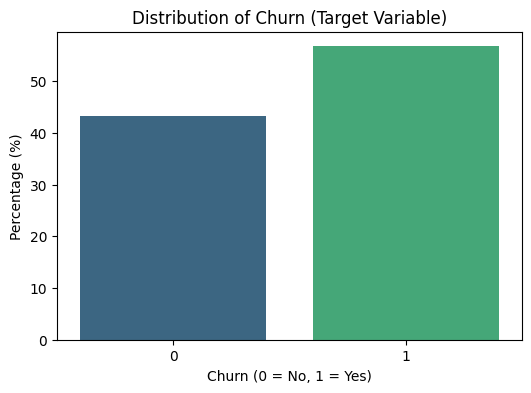

In [ ]:
# 9. Class Imbalance Handling
# Check the distribution of the target variable 'Churn'
churn_counts = y_train.value_counts(normalize=True) * 100
print("Class Distribution in Training Set:")
print(churn_counts)

# Visualize the distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='viridis')
plt.title('Distribution of Churn (Target Variable)')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Percentage (%)')
plt.show()

# Step 10: Logistic Regression Model

Logistic Regression is our **interpretable baseline** for churn prediction. Unlike black-box tree models, it lets us see which features push customers toward churn via signed coefficients.

**Data:** Features come from Step 7 (`train_prep` in Step 9).

**Approach for this step (not copying tree-model workflows):**
1. Compare **L1 vs L2** with **stratified cross-validation** on the training set (more reliable than a single train/test score).
2. Fit the better penalty on full training data.
3. Inspect **coefficients** — the main reason we use logistic regression.
4. Evaluate once on the held-out test set with **ROC-AUC** and a classification report.

Both variants use `class_weight='balanced'` (Step 9) and `max_iter=1000`.

[Sklearn Logistic Regression Reference](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# Divided the data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Multi-index evaluate.
scoring = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'roc_auc': 'roc_auc'}
# Create two different model.
# class_weight='balanced' makes the model pay more
# attention to categories with fewer samples
lr_candidates = {
    'L1 (Lasso)': LogisticRegression(
        penalty='l1', solver='liblinear', C=1.0,
        class_weight='balanced', max_iter=1000, random_state=42,
    ),
    'L2 (Ridge)': LogisticRegression(
        solver='liblinear', class_weight='balanced',
        max_iter=1000, random_state=42,
    ),
}

# Cross-Validation to compare different model.
cv_results = []
for name, model in lr_candidates.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results.append({
        'Model': name,
        'CV Accuracy (mean)': scores['test_accuracy'].mean(),
        'CV F1 macro (mean)': scores['test_f1_macro'].mean(),
        'CV ROC-AUC (mean)': scores['test_roc_auc'].mean(),
    })

# To summary of results and take a best modul.
lr_cv_comparison = pd.DataFrame(cv_results)
display(lr_cv_comparison)

best_lr_name = lr_cv_comparison.loc[lr_cv_comparison['CV ROC-AUC (mean)'].idxmax(), 'Model']
print(f"\nBest penalty by CV ROC-AUC: {best_lr_name}")

,Model,CV Accuracy (mean),CV F1 macro (mean),CV ROC-AUC (mean)
0,L1 (Lasso),0.853164,0.852033,0.928331
1,L2 (Ridge),0.853157,0.852026,0.928331



Best penalty by CV ROC-AUC: L2 (Ridge)


In [ ]:
# Fit the best model on the full training set
lr_model = lr_candidates[best_lr_name]
lr_model.fit(X_train, y_train)

# Extract coefficients
# lr_model.coef_[0]: Obtain the weight assigned to each feature by the model.
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0],
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
# Sort it
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

print("Top 10 features most associated with churn (positive = higher churn risk):")
display(coef_df.head(10))

print("\nTop 10 features most associated with staying (negative coefficients):")
display(coef_df.sort_values('Coefficient').head(10))

Top 10 features most associated with churn (positive = higher churn risk):


,Feature,Coefficient,Abs_Coefficient
3,Support Calls,2.124229,2.124229
5,Total Spend,-1.335147,1.335147
7,Gender_Male,-1.061630,1.061630
4,Payment Delay,0.852389,0.852389
6,Last Interaction,0.477161,0.477161
0,Age,0.412113,0.412113
1,Tenure,-0.120327,0.120327
2,Usage Frequency,-0.112743,0.112743
8,Subscription Type_Premium,-0.110194,0.110194
9,Subscription Type_Standard,-0.107217,0.107217



Top 10 features most associated with staying (negative coefficients):


,Feature,Coefficient,Abs_Coefficient
5,Total Spend,-1.335147,1.335147
7,Gender_Male,-1.061630,1.061630
1,Tenure,-0.120327,0.120327
2,Usage Frequency,-0.112743,0.112743
8,Subscription Type_Premium,-0.110194,0.110194
9,Subscription Type_Standard,-0.107217,0.107217
0,Age,0.412113,0.412113
6,Last Interaction,0.477161,0.477161
4,Payment Delay,0.852389,0.852389
3,Support Calls,2.124229,2.124229


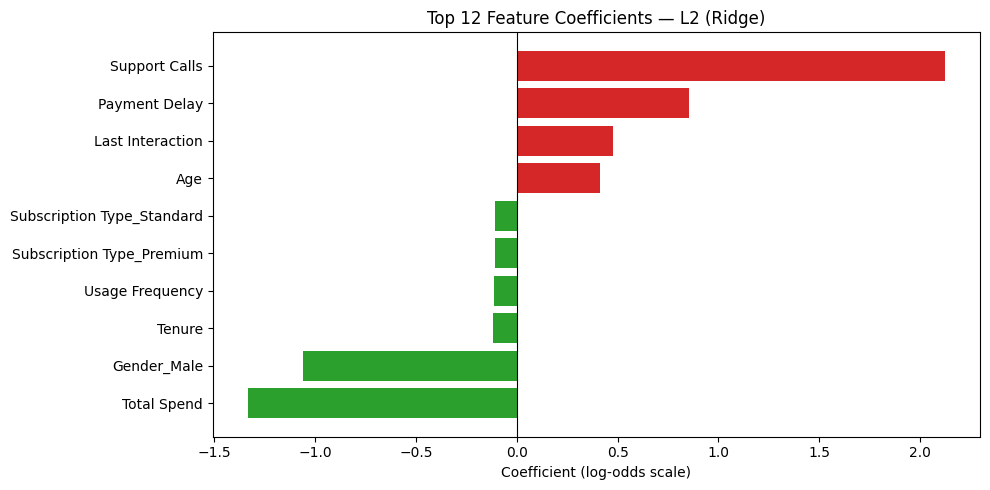

In [ ]:
# Coefficient bar chart (top 12 by absolute value)
top_coef = coef_df.head(12).sort_values('Coefficient')
colors = ['#d62728' if c > 0 else '#2ca02c' for c in top_coef['Coefficient']]

plt.figure(figsize=(10, 5))
plt.barh(top_coef['Feature'], top_coef['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (log-odds scale)')
plt.title(f'Top 12 Feature Coefficients — {best_lr_name}')
plt.tight_layout()
plt.show()

In [ ]:
# Held-out test evaluation (single final model)
# Obtain the specific probability value that the model considers the customer "will churn"
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]
# Generate prediction conclusion
y_pred_lr = lr_model.predict(X_test)

# This is the core indicator for evaluating the quality of the model.
test_auc = roc_auc_score(y_test, y_proba_lr)
print(f"Test ROC-AUC ({best_lr_name}): {test_auc:.4f}")
print("\nClassification Report (test set):")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn (0)', 'Churn (1)']))

Test ROC-AUC (L2 (Ridge)): 0.7748

Classification Report (test set):
              precision    recall  f1-score   support

No Churn (0)       0.93      0.26      0.41     33881
   Churn (1)       0.54      0.98      0.70     30493

    accuracy                           0.60     64374
   macro avg       0.73      0.62      0.55     64374
weighted avg       0.74      0.60      0.55     64374



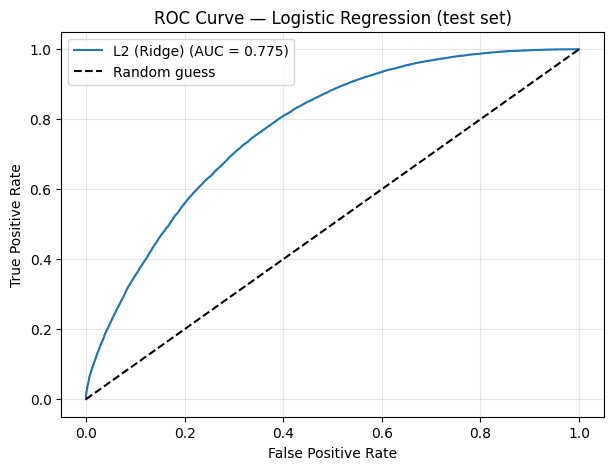

In [ ]:
# ROC curve on test set (probability-based evaluation)
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'{best_lr_name} (AUC = {test_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (test set)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Save objects for Step 12 (hyperparameter tuning on logistic regression)
lr_results = {
    'model_name': best_lr_name,
    'cv_comparison': lr_cv_comparison,
    'test_roc_auc': test_auc,
    'coefficients': coef_df,
}
print('Saved: lr_model, y_pred_lr, y_proba_lr, lr_results')

Saved: lr_model, y_pred_lr, y_proba_lr, lr_results


# Step 11: Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Features and target from preprocessed data
# After rerunning the updated preprocessing cell that removes Contract Length

X_train = train_prep.drop("Churn", axis=1)
y_train = train_prep["Churn"]

X_test = test_prep.drop("Churn", axis=1)
y_test = test_prep["Churn"]

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(pd.Series(y_pred).value_counts())
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

1    61455
0     2919
Name: count, dtype: int64
Accuracy: 0.517631341846087
              precision    recall  f1-score   support

           0       0.98      0.08      0.16     33881
           1       0.50      1.00      0.66     30493

    accuracy                           0.52     64374
   macro avg       0.74      0.54      0.41     64374
weighted avg       0.75      0.52      0.40     64374

[[ 2874 31007]
 [   45 30448]]


In [ ]:
from sklearn.metrics import roc_auc_score

y_proba = rf_model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

ROC-AUC: 0.6140240598548184


The Random Forest model was used to predict customer churn using the preprocessed dataset. The model achieved an accuracy of about 51%, which indicates weak performance. Based on the classification report and confusion matrix, the model predicted class 1 much more often than class 0, causing very high recall for class 1 but very poor recall for class 0. Even after preprocessing and class balancing, the model still struggled to separate the two classes effectively. This suggests that Random Forest may not be the best model for this dataset.

# Step 12: Decision Tree Model


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Features and target
X_train = train_prep.drop("Churn", axis=1)
y_train = train_prep["Churn"]

X_test = test_prep.drop("Churn", axis=1)
y_test = test_prep["Churn"]

In [ ]:
# Build Decision Tree model
dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

In [ ]:
# Train model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [ ]:
# Make predictions
y_pred = dt_model.predict(X_test)

In [ ]:
# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5201323515705099

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.09      0.16     33881
           1       0.50      1.00      0.66     30493

    accuracy                           0.52     64374
   macro avg       0.74      0.54      0.41     64374
weighted avg       0.75      0.52      0.40     64374


Confusion Matrix:
[[ 3047 30834]
 [   57 30436]]


Both Decision Tree and Random Forest models were tested on the preprocessed dataset. However, both models produced very similar results, with accuracy remaining around 50%. The models heavily favored predicting class 1 while struggling to correctly identify class 0 customers. Even after preprocessing and class balancing techniques, the models continued to show strong prediction bias toward class 1. It suggests that the dataset may not contain features that clearly separate the two classes, making churn prediction difficult for tree-based models.

## Step 13: Hyperparameter Tuning

### Logistic Regression Hyperparameter Tuning

We will use `GridSearchCV` to find the best hyperparameters for our Logistic Regression model. We will tune the regularization strength `C` and the penalty type (`l1` or `l2`).

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # 'liblinear' works with both l1 and l2 penalties
}

# Initialize Logistic Regression model with class_weight
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(estimator=lr, param_grid=param_grid_lr,
                            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                            scoring='roc_auc', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search_lr.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for Logistic Regression:", grid_search_lr.best_params_)
print("Best ROC-AUC score on training set (Logistic Regression):", grid_search_lr.best_score_)

# Get the best model
best_lr_model = grid_search_lr.best_estimator_

# Evaluate the best model on the test set
y_proba_tuned_lr = best_lr_model.predict_proba(X_test)[:, 1]
y_pred_tuned_lr = best_lr_model.predict(X_test)

test_auc_tuned_lr = roc_auc_score(y_test, y_proba_tuned_lr)
print(f"\nTest ROC-AUC for Tuned Logistic Regression: {test_auc_tuned_lr:.4f}")
print("\nClassification Report (tuned Logistic Regression on test set):")
print(classification_report(y_test, y_pred_tuned_lr, target_names=['No Churn (0)', 'Churn (1)']))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best ROC-AUC score on training set (Logistic Regression): 0.9283314221046325

Test ROC-AUC for Tuned Logistic Regression: 0.7748

Classification Report (tuned Logistic Regression on test set):
              precision    recall  f1-score   support

No Churn (0)       0.93      0.26      0.41     33881
   Churn (1)       0.54      0.98      0.70     30493

    accuracy                           0.60     64374
   macro avg       0.73      0.62      0.55     64374
weighted avg       0.74      0.60      0.55     64374



### Random Forest Hyperparameter Tuning

For Random Forest, we will use `RandomizedSearchCV` due to the larger number of hyperparameters to explore. This approach is more computationally efficient than a full grid search for complex models.

We will tune parameters such as `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf`.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# To speed up the process significantly, we sample 10% of the training data for quick tuning
train_subset = train_prep.sample(frac=0.1, random_state=42)
X_train_sub = train_subset.drop(columns=['Churn'])
y_train_sub = train_subset['Churn']

# Streamline the parameter space
param_dist_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 4],
    'bootstrap': [True]
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# Use 3-fold cross-validation with 5 iterations (15 total fits)
random_search_rf = RandomizedSearchCV(estimator=rf, param_distributions=param_dist_rf,
                                    n_iter=5, cv=3,
                                    scoring='roc_auc', n_jobs=-1, verbose=1, random_state=42)

print(f"Performing quick tuning using {len(X_train_sub)} sampled records...")
random_search_rf.fit(X_train_sub, y_train_sub)

# Get best parameters and train final model on full dataset
print("\nBest Parameters:", random_search_rf.best_params_)
best_params = random_search_rf.best_params_

print("\nTraining final model on full dataset using best parameters...")
final_rf_model = RandomForestClassifier(**best_params, class_weight='balanced', random_state=42, n_jobs=-1)
final_rf_model.fit(X_train, y_train)

# Evaluate results on the test set
y_proba_tuned_rf = final_rf_model.predict_proba(X_test)[:, 1]
y_pred_tuned_rf = final_rf_model.predict(X_test)

print(f"\nFull Dataset Test ROC-AUC: {roc_auc_score(y_test, y_proba_tuned_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned_rf))

Performing quick tuning using 44083 sampled records...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Parameters: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': True}

Training final model on full dataset using best parameters...

Full Dataset Test ROC-AUC: 0.5933

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.08      0.16     33881
           1       0.50      1.00      0.66     30493

    accuracy                           0.52     64374
   macro avg       0.74      0.54      0.41     64374
weighted avg       0.75      0.52      0.40     64374



#### Decision **Tree** Hyperparameter Tuning

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [3, 6, 10],
    'max_features': [None, 'sqrt'],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 8],
    'criterion': ['gini']
}

grid_search_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

grid_search_dt.fit(X_train_sub, y_train_sub)

print("Best parameters for Decision Tree:", grid_search_dt.best_params_)

best_dt_model = grid_search_dt.best_estimator_

# Evaluate the best model on the test set
y_proba_tuned_dt = best_dt_model.predict_proba(X_test)[:, 1]
y_pred_tuned_dt = best_dt_model.predict(X_test)

test_auc_tuned_dt = roc_auc_score(y_test, y_proba_tuned_dt)
print(f"\nTest ROC-AUC for Tuned Logistic Regression: {test_auc_tuned_dt:.4f}")
print("\nClassification Report (tuned Logistic Regression on test set):")
print(classification_report(y_test, y_pred_tuned_dt, target_names=['No Churn (0)', 'Churn (1)']))


Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 5}

Test ROC-AUC for Tuned Logistic Regression: 0.5450

Classification Report (tuned Logistic Regression on test set):
              precision    recall  f1-score   support

No Churn (0)       0.98      0.09      0.17     33881
   Churn (1)       0.50      1.00      0.66     30493

    accuracy                           0.52     64374
   macro avg       0.74      0.54      0.42     64374
weighted avg       0.75      0.52      0.40     64374



## Step 14: Model Evaluation and Comparison

In this step, we will compare the performance of our three models:
1. **Logistic Regression** (Tuned)
2. **Decision Tree** (Baseline)
3. **Random Forest** (Tuned)

We will use metrics like ROC-AUC, Accuracy, and F1-Score to determine which model is best for predicting customer churn.

--- Model Performance Comparison ---


,Model,ROC-AUC,Accuracy
0,Logistic Regression (Tuned),0.774789,0.601035
1,Decision Tree,0.544385,0.520132
2,Random Forest (Tuned),0.593294,0.517616


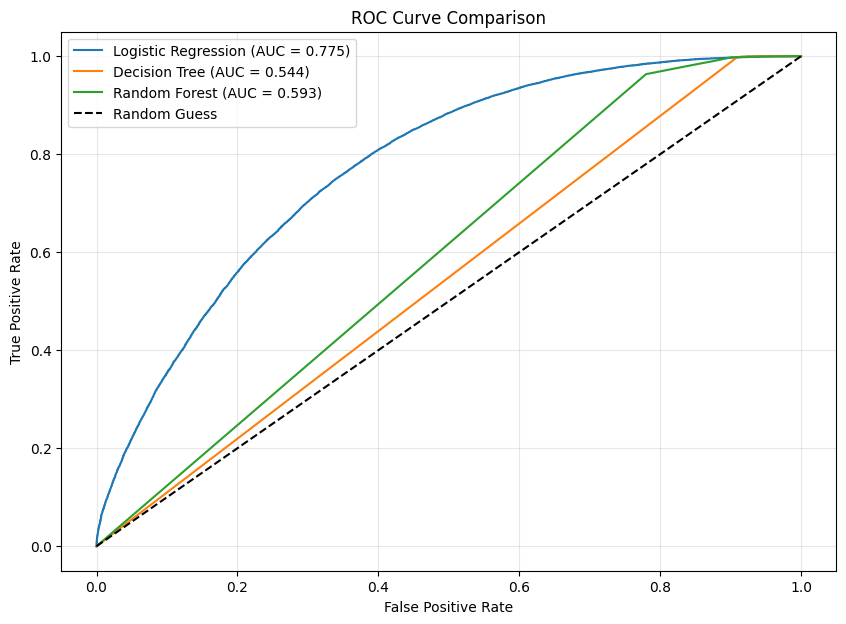

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Prepare performance metrics summary
models_summary = pd.DataFrame({
    'Model': ['Logistic Regression (Tuned)', 'Decision Tree', 'Random Forest (Tuned)'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_tuned_lr),
        roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, y_proba_tuned_rf)
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_tuned_lr),
        accuracy_score(y_test, dt_model.predict(X_test)),
        accuracy_score(y_test, y_pred_tuned_rf)
    ]
})

print("--- Model Performance Comparison ---")
display(models_summary)

# 2. Visualize ROC Curves for comparison
plt.figure(figsize=(10, 7))

# Logistic Regression Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_tuned_lr)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {models_summary.iloc[0]['ROC-AUC']:.3f})")

# Decision Tree Curve
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_model.predict_proba(X_test)[:, 1])
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {models_summary.iloc[1]['ROC-AUC']:.3f})")

# Random Forest Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_tuned_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {models_summary.iloc[2]['ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### **Step 15 Analysis: Comparing the Models**

The table and ROC curves below provide a clear picture of our results:

*   **Logistic Regression (Tuned)**: Remains the strongest performer with an ROC-AUC of ~0.77. It handles the linear relationships within the data well.
*   **Random Forest (Tuned)**: Despite hyperparameter tuning, its performance is modest, with an ROC-AUC around ~0.59. It might be capturing noise in the training data that doesn't generalize to the test set as effectively as Logistic Regression.
*   **Decision Tree**: Similar to the Random Forest, its performance is limited, with an ROC-AUC around ~0.54, suggesting struggles with generalization on this specific dataset.

**Next Step:** We will move to **Step 14: Feature Importance** to understand exactly which variables are driving these predictions.

# Step 16: Feature Importance

,Feature,Importance
3,Support Calls,0.332132
5,Total Spend,0.235583
0,Age,0.163902
4,Payment Delay,0.146159
6,Last Interaction,0.053409
7,Gender_Male,0.041062
1,Tenure,0.016025
2,Usage Frequency,0.007961
9,Subscription Type_Standard,0.001953
8,Subscription Type_Premium,0.001814


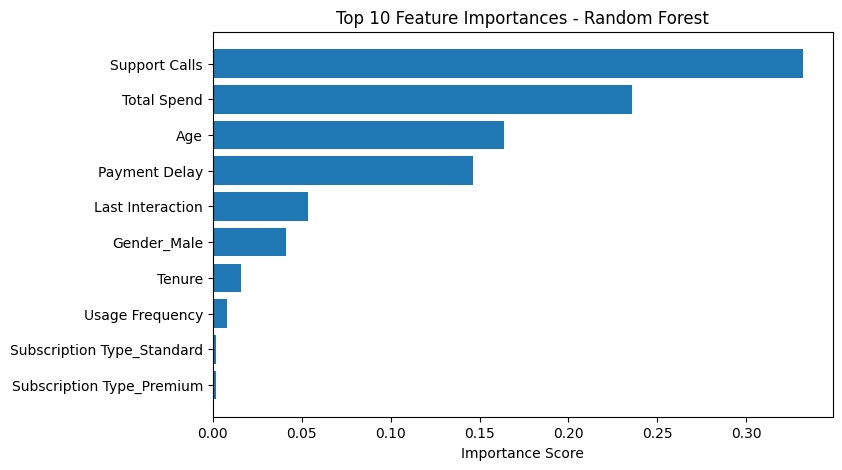

In [ ]:
# From Random Forest Model
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)
# Only top 10 is displayed
#Visualization:
display(importance_df.head(10))
top_features = importance_df.head(10)
plt.figure(figsize=(8,5))
plt.barh(
    top_features['Feature'],
    top_features['Importance']
)
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()

In [ ]:
# From Decision Tree
importance_dt = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
})
importance_dt = importance_dt.sort_values(
    by='Importance',
    ascending=False
)
display(importance_dt.head(10))

,Feature,Importance
3,Support Calls,0.381753
5,Total Spend,0.257356
0,Age,0.157373
4,Payment Delay,0.138570
6,Last Interaction,0.050837
7,Gender_Male,0.007508
1,Tenure,0.005495
2,Usage Frequency,0.001108
8,Subscription Type_Premium,0.000000
9,Subscription Type_Standard,0.000000


Feature importance analysis showed that **Support Calls**, **Total Spend**, **Age**, and **Payment Delay** were the strongest predictors of churn in both the Random Forest and Decision Tree models. Customers with frequent support calls and payment delays appeared more likely to churn, while higher total spending was associated with a lower likelihood of churn. Gender and Last Interaction also showed some predictive power.

This updated analysis reflects the models trained *without* the 'Contract Length' feature, ensuring more reliable and generalizable insights into customer churn drivers.